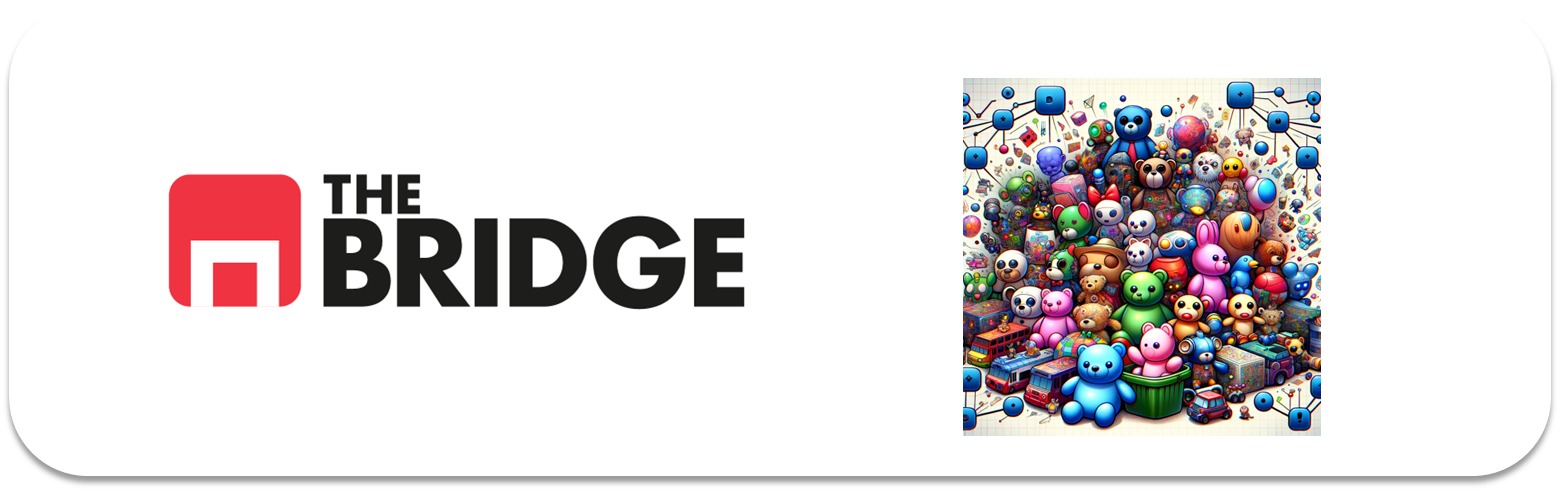

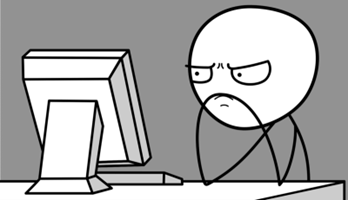

Para ejercitarte y afianzar lo aprendido sobre **K-Means**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import seaborn as sns
import os

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

from toolbox_ml.eda.core import (
    describe_df, tipifica_variables, 
    get_features_num_regression, 
    plot_features_num_regression, 
    get_features_cat_regression, 
    plot_features_cat_regression
)


import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

### Entendiendo el problema de negocio

En este notebook vamos a hacer un análisis de datos tirando de clusterizaciones para evaluar si existen grupos en nuestros productos, en este caso medicamentos, y posteriormente poder etiquetarlos. Poseemos información como rating, efectividad, efectos secundarios, entre otros.

### Ejercicio 1

Importa los datos, "./data/drugLibTrain_raw.tsv", que contiene un dataset con diferentes fármacos, sus efectos y ratings de los clientes de dichos fármacos. Realiza una inspección preliminar y quita las columnas que consideres innecesarias.

In [2]:
df = pd.read_csv("./data/drugLibTrain_raw.tsv", sep="\t")
df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


In [4]:
tipifica_variables(df, umbral_categoria=11, umbral_continua=25)

,nombre_variable,tipo_sugerido
0,Unnamed: 0,Numérica Continua
1,urlDrugName,Numérica Discreta
2,rating,Categórica
3,effectiveness,Categórica
4,sideEffects,Categórica
5,condition,Numérica Continua
6,benefitsReview,Numérica Continua
7,sideEffectsReview,Numérica Continua
8,commentsReview,Numérica Continua


In [5]:
# Eliminamos la primera columna ya que son índices sin ninguna información
df.drop(columns='Unnamed: 0', inplace=True)

df

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above
...,...,...,...,...,...,...,...,...
3102,vyvanse,10,Highly Effective,Mild Side Effects,adhd,"Increased focus, attention, productivity. Bett...","Restless legs at night, insomnia, headache (so...","I took adderall once as a child, and it made m..."
3103,zoloft,1,Ineffective,Extremely Severe Side Effects,depression,Emotions were somewhat blunted. Less moodiness.,"Weight gain, extreme tiredness during the day,...",I was on Zoloft for about 2 years total. I am ...
3104,climara,2,Marginally Effective,Moderate Side Effects,total hysterctomy,---,Constant issues with the patch not staying on....,---
3105,trileptal,8,Considerably Effective,Mild Side Effects,epilepsy,Controlled complex partial seizures.,"Dizziness, fatigue, nausea",Started at 2 doses of 300 mg a day and worked ...


### Ejercicio 2: MiniEDA

Como es un problema no supervisado (vamos a intentar agrupar los medicamentos sin tener una referencia o target inicial), no hay split, vamos directos al miniEDA. Analiza qué variables son descartables en función de su porcentaje de cardinalidad. Es decir obten la cardinalidad y su porcentaje para cada posible feature y crea un dataset nuevo descartando las features que creas conveniente. NOTA: Como simplificación, descarta la columna con url.

In [6]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
urlDrugName,object,0.0,502,16.16
rating,int64,0.0,10,0.32
effectiveness,object,0.0,5,0.16
sideEffects,object,0.0,5,0.16
condition,object,0.03,1426,45.9
benefitsReview,object,0.58,3031,97.55
sideEffectsReview,object,2.41,2813,90.54
commentsReview,object,0.39,3046,98.04


In [7]:
cols_drop = ['urlDrugName', 'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview'] # Las eliminamos por su alta cardinalidad
df2 = df.drop(columns=cols_drop, errors='ignore')

print(df2.shape)   # (3107, 3)
print(df2.head())

(3107, 3)
   rating         effectiveness          sideEffects
0       4      Highly Effective    Mild Side Effects
1       1      Highly Effective  Severe Side Effects
2      10      Highly Effective      No Side Effects
3       3  Marginally Effective    Mild Side Effects
4       2  Marginally Effective  Severe Side Effects


### Ejercicio 3

Construye un train set (llámalo X) sólo con las features que hayas seleccionado del ejercicio anterior (es decir las que no hayas descartado como posibles features) 

In [8]:
X = df2.copy()

### Ejercicio 4 

Trasforma las features que consideres necesario (categóricas y numéricas) y luego aplica el escalado que consideres necesario.

In [9]:
# Definimos el orden explícito de cada variable ordinal
effectiveness_order = [
    'Ineffective',
    'Marginally Effective', 
    'Moderately Effective',
    'Considerably Effective',
    'Highly Effective'
]

side_effects_order = [
    'No Side Effects',
    'Mild Side Effects',
    'Moderate Side Effects',
    'Severe Side Effects',
    'Extremely Severe Side Effects'
]

# Encoding ordinal
encoder = OrdinalEncoder(categories=[effectiveness_order, side_effects_order])
X_encoded = X.copy()
X_encoded[['effectiveness', 'sideEffects']] = encoder.fit_transform(X[['effectiveness', 'sideEffects']])

# Escalado
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_encoded),
    columns=X_encoded.columns,
    index=X_encoded.index
)

print(X_scaled.head())
print(X_scaled.describe().round(2))

     rating  effectiveness  sideEffects
0 -1.023494       0.865108    -0.258895
1 -2.044907       0.865108     1.439917
2  1.019330       0.865108    -1.108302
3 -1.363965      -1.573256    -0.258895
4 -1.704436      -1.573256     1.439917
        rating  effectiveness  sideEffects
count  3107.00        3107.00      3107.00
mean     -0.00          -0.00        -0.00
std       1.00           1.00         1.00
min      -2.04          -2.39        -1.11
25%      -0.68          -0.76        -1.11
50%       0.34           0.05        -0.26
75%       0.68           0.87         0.59
max       1.02           0.87         2.29


### Ejercicio 5: Otención de K, aproximación visual

Analiza la relación entre features (con scatter plots) una vez transformadas para comprobar si existe visualmente algún indicio del número de clústeres que podríamos estar buscando. Por otro lado este análisis nos puede hacer descartar alguna feature o generar una nueva

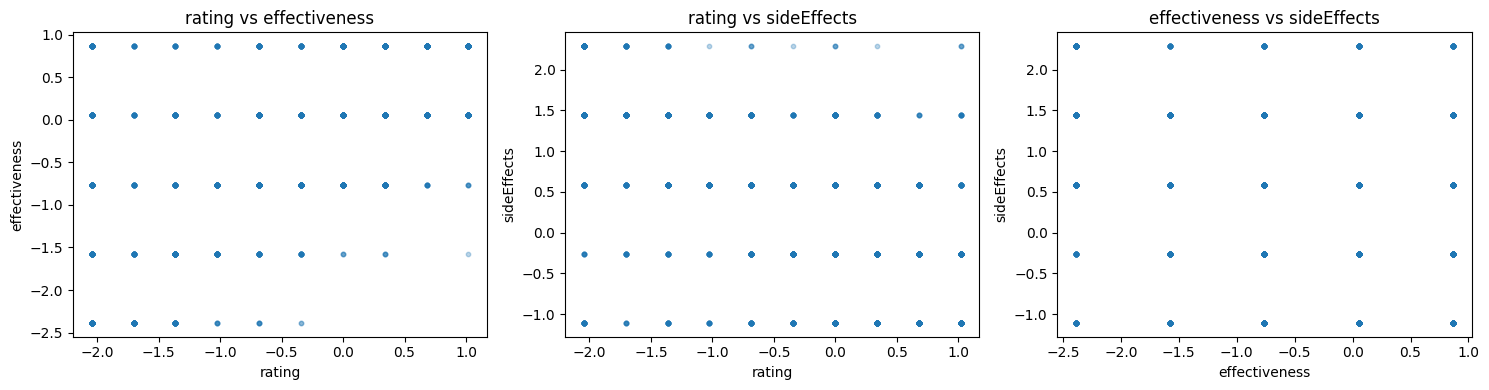

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    ('rating', 'effectiveness'),
    ('rating', 'sideEffects'),
    ('effectiveness', 'sideEffects')
]

for ax, (x_col, y_col) in zip(axes, pairs):
    ax.scatter(X_scaled[x_col], X_scaled[y_col], alpha=0.3, s=10)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')

plt.tight_layout()
plt.show()

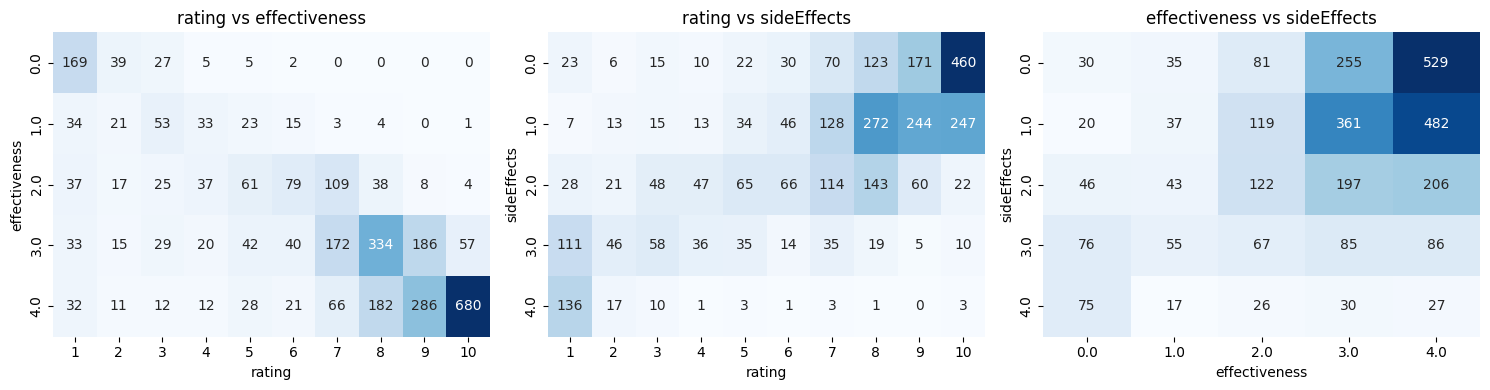

In [11]:
# Heatmap de frecuencias — mucho más informativo para datos discretos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (x_col, y_col) in zip(axes, pairs):
    pivot = X_encoded.groupby([y_col, x_col]).size().unstack(fill_value=0)
    sns.heatmap(pivot, ax=ax, cmap='Blues', annot=True, fmt='d', cbar=False)
    ax.set_title(f'{x_col} vs {y_col}')

plt.tight_layout()
plt.show()

### Ejercicio 6: Obtención de K, método del codo

Evalua diferentes valores K y escoge uno a partir del método del codo/elbow de inercia.

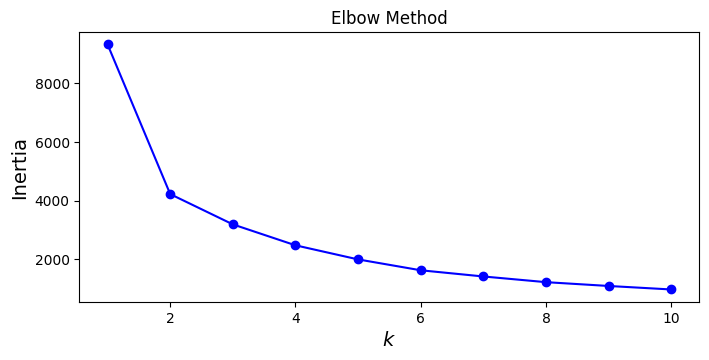

In [12]:
kmeans_per_k = [
    KMeans(n_clusters=k, random_state=42, n_init=25).fit(X_scaled)
    for k in range(1,11)
]

inertias = [model.inertia_ for model in kmeans_per_k]


plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 11), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.title("Elbow Method")
plt.show()

In [13]:
# Conclusión elbow
print(f"Inercia k=2: {inertias[1]:.1f}")
print(f"Inercia k=3: {inertias[2]:.1f}")
print(f"Inercia k=4: {inertias[3]:.1f}")
print(f"Inercia k=5: {inertias[4]:.1f}")

Inercia k=2: 4226.6
Inercia k=3: 3195.5
Inercia k=4: 2482.9
Inercia k=5: 2002.5


Con estos datos de Elbow escogería k=3

### Ejercicio 7: Obtención de K, Score de Silueta

Comprueba el ajuste de k obteniendo el k que maximiza el score de silueta y pinta un gráfico de la evolución de dicho score con k. Usa los valores de k que hayas probado en el ejercicio anterior.

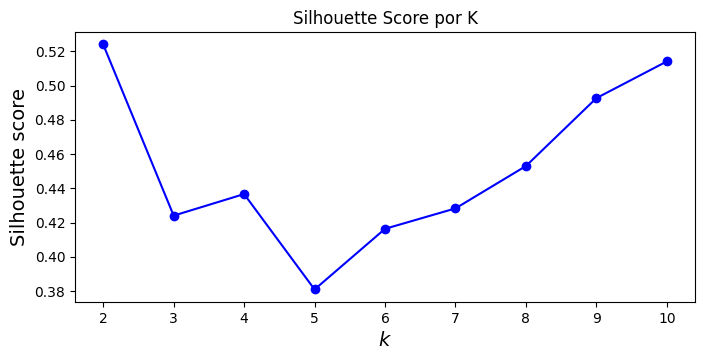

{2: 0.524, 3: 0.424, 4: 0.4366, 5: 0.3809, 6: 0.4163, 7: 0.4283, 8: 0.453, 9: 0.4927, 10: 0.5141}


In [14]:
silhouette_scores = [
    silhouette_score(X_scaled, model.labels_)
    for model in kmeans_per_k[1:]  # k>=2
]

plt.figure(figsize=(8, 3.5))
plt.plot(range(2, 11), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score por K")
plt.show()

print({k+2: round(s, 4) for k, s in enumerate(silhouette_scores)})

Con esto datos selecciono k=2

### Ejercicio 8: Obtención de K, diagrama de silueta

Para completar el estudio de k, muestra el diagramde silueta para k=2,3,4,5 y decide con este datos y los anteriores el valor de k a probar. NOTA: En la realidad, podríamos probar perfectamente k=2 y k=3 y luego que "Negocio" decidiera cuál le es más útil, aquí lo completamos por practicar todo lo aprendido

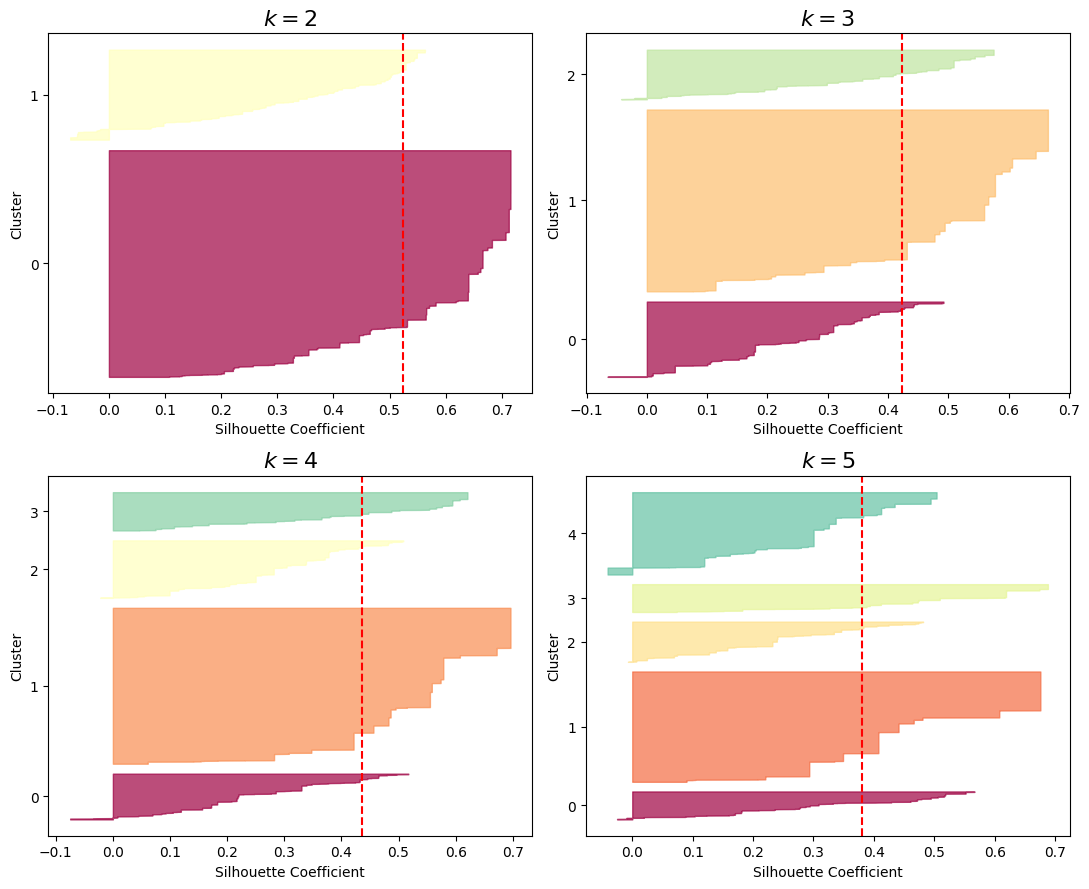

In [16]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

for idx, k in enumerate([2, 3, 4, 5]):
    plt.subplot(2, 2, idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X_scaled, y_pred)

    padding = len(X_scaled) // 30
    pos = padding
    ticks = []

    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")
    plt.xlabel("Silhouette Coefficient")
    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=16)

plt.tight_layout()
plt.show()

### Ejercico 9:

En general, una diferencia entre el proceso de construcción de un modelo no supervisado y un supervisado es que el ajuste de algunos hiperparámetros (como el número de clústeres) es anterior a la construcción del modelo. Por eso, construye un K-means para el valor (o valores) de K escogidos.

In [17]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=25)
kmeans_final.fit(X_scaled)

print("Inercia:", round(kmeans_final.inertia_, 2))
print("Silhouette score:", round(silhouette_score(X_scaled, kmeans_final.labels_), 4))
print("Distribución de clusters:\n", pd.Series(kmeans_final.labels_).value_counts().sort_index())

Inercia: 3195.49
Silhouette score: 0.424
Distribución de clusters:
 0     763
1    1841
2     503
Name: count, dtype: int64


### Ejercicio 10

Vamos a comprobar resultados, analizando los valores medios y distribución de cada uno de los clústeres para el k óptimo. Si tuvieras más de un posible valor de k a probar, analiza aquí el de mayor score de silueta. Y utiliza el siguiente ejercicio para el otro. Además de hacer un describe de las features por clúster, pinta estos con un pairplot considerando sideEffects y rating como x e y (o viceversa) y el clúster como hue (color). Compara el resultado con los clústeres sugeridos en el ejercicio 5.

         rating                                       
          count  mean   std  min  25%  50%   75%   max
cluster                                               
0         763.0  5.71  2.26  1.0  4.0  6.0   8.0  10.0
1        1841.0  8.87  1.17  4.0  8.0  9.0  10.0  10.0
2         503.0  2.17  1.41  1.0  1.0  2.0   3.0   7.0


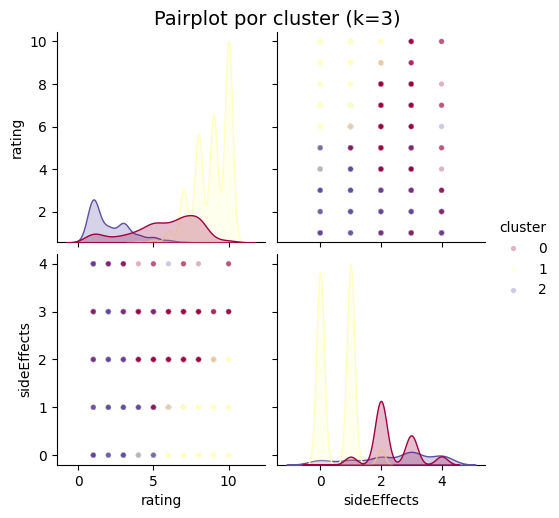

In [20]:
# Usamos los valores ya codificados numéricamente
X_clusters_enc = X_encoded.copy()
X_clusters_enc['cluster'] = kmeans_final.labels_

# Describe por cluster (sobre datos originales para legibilidad)
print(X_clusters.groupby('cluster').describe().round(2))

# Pairplot con valores numéricos
sns.pairplot(
    X_clusters_enc,
    vars=['rating', 'sideEffects'],
    hue='cluster',
    plot_kws={'alpha': 0.3, 's': 15},
    palette='Spectral'
)
plt.suptitle("Pairplot por cluster (k=3)", y=1.02, fontsize=14)
plt.show()

### Ejercicio 11, EXTRA: Más valores de K

Repite el análisis del ejercicio 10 para un K diferente pero que consideres que tiene sentido aplicar.

         rating                                       
          count  mean   std  min  25%  50%   75%   max
cluster                                               
0        2224.0  8.59  1.33  1.0  8.0  9.0  10.0  10.0
1         883.0  3.03  1.95  1.0  1.0  3.0   5.0  10.0


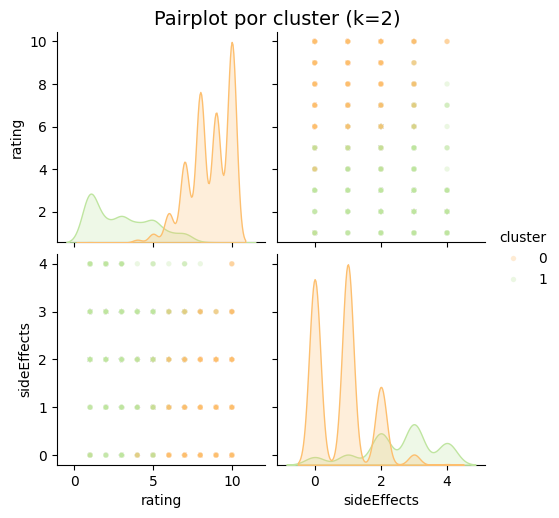

In [21]:
kmeans_k2 = kmeans_per_k[1]  # k=2, ya entrenado

X_clusters_k2 = X.copy()
X_clusters_k2['cluster'] = kmeans_k2.labels_

X_clusters_enc_k2 = X_encoded.copy()
X_clusters_enc_k2['cluster'] = kmeans_k2.labels_

# Describe por cluster
print(X_clusters_k2.groupby('cluster').describe().round(2))

# Pairplot
sns.pairplot(
    X_clusters_enc_k2,
    vars=['rating', 'sideEffects'],
    hue='cluster',
    plot_kws={'alpha': 0.3, 's': 15},
    palette='Spectral'
)
plt.suptitle("Pairplot por cluster (k=2)", y=1.02, fontsize=14)
plt.show()